In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
from os.path import join as pjoin

from cns.process.segmentation import add_cns_loc, aggregate_by_break_type, group_samples, aggregate_by_segments, sum_cns
from cns.display.plot import fig_lines, fig_dots, fig_bars, plot_lines, plot_dots, plot_bars, fig_CN_heatmap, plot_CN_heatmap
from cns.process.segments import merge_segments, filter_min_size, segment_difference, split_segments
from cns.display.label import add_gap_legend, plot_gaps
from cns.utils.conversions import genome_to_segments, tuples_to_segments, df_to_segs
from cns.utils.selection import cns_head, drop_Y
from cns.utils.assemblies import hg19
from cns.data_utils import load_cns_out, out_path, load_COSMIC, save_doc_fig, docs_path

In [3]:
pcawg_cns_df = sum_cns(add_cns_loc(load_cns_out("PCAWG_cns_imp.tsv")))
pcawg_cns_df.head()

,sample_id,chrom,start,end,major_cn,minor_cn,length,mid,cum_mid,total_cn
0,SP101724,chr1,0,27256755,2,2,27256755,13628377,13628377,4
1,SP101724,chr1,27256755,28028200,3,2,771445,27642477,27642477,5
2,SP101724,chr1,28028200,32976095,2,2,4947895,30502147,30502147,4
3,SP101724,chr1,32976095,33354394,5,2,378299,33165244,33165244,7
4,SP101724,chr1,33354394,33554783,3,2,200389,33454588,33454588,5


In [7]:
genes_segs = df_to_segs(load_COSMIC())
genes_segs

{'chr1': [(2160133, 2241558),
  (2487077, 2496821),
  (2985731, 3355185),
  (6241328, 6269449),
  (6845383, 7829766),
  (11166591, 11322564),
  (14026692, 14151574),
  (15817326, 15853029),
  (16174358, 16266955),
  (17345216, 17380665),
  (17866329, 18024369),
  (18957499, 19075360),
  (23884408, 23886285),
  (23907984, 23967058),
  (27022523, 27108595),
  (32716839, 32751766),
  (35641978, 35658749),
  (36690016, 36770958),
  (36931643, 36948879),
  (40361097, 40367928),
  (43803477, 43818443),
  (45794834, 45806142),
  (47681961, 47697892),
  (47715810, 47779819),
  (51426416, 51440305),
  (51819934, 51985000),
  (59246464, 59249785),
  (65298911, 65432187),
  (78409739, 78444794),
  (85731930, 85742773),
  (93297581, 93307481),
  (110881127, 110889299),
  (114935398, 115053781),
  (115247089, 115259515),
  (116915289, 116952883),
  (120454175, 120612240),
  (144836156, 145076186),
  (147013181, 147098017),
  (150782180, 150849244),
  (150898738, 150937213),
  (151030233, 151040970)

In [9]:
pcawg_1_bin_df = add_cns_loc(aggregate_by_break_type(cns_head(pcawg_cns_df, 1), 100_000))
pcawg_1_groups_df = group_samples(pcawg_1_bin_df)

pcawg_10_bin_df = add_cns_loc(aggregate_by_break_type(cns_head(pcawg_cns_df, 10), 1_000_000))
pcawg_10_groups_df = group_samples(pcawg_10_bin_df)

pcawg_50_bin_df = add_cns_loc(aggregate_by_break_type(cns_head(pcawg_cns_df, 50), 10_000_000))
pcawg_50_groups_df = group_samples(pcawg_50_bin_df)

pcawg_arms_bin_df = add_cns_loc(aggregate_by_break_type(cns_head(pcawg_cns_df, 10), "arms"))
pcawg_arms_groups_df = group_samples(pcawg_arms_bin_df)

gene_bin_df = add_cns_loc(aggregate_by_segments(cns_head(pcawg_cns_df, 10), genes_segs))
gene_groups_df = group_samples(gene_bin_df)

Aggregated into 30363 CNS.                                        
Aggregated into 30399 CNS.                                        
Aggregated into 15256 CNS.                                        
Aggregated into 462 CNS.                                        
Aggregated into 7220 CNS.                                        


# Plots

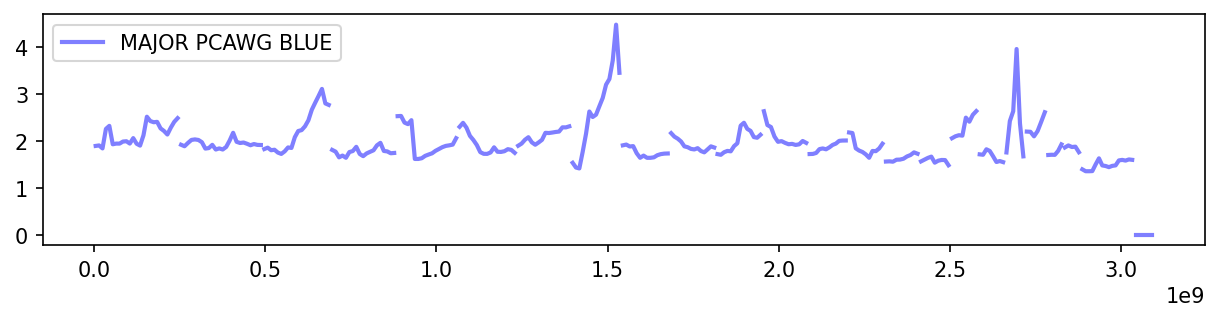

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(10, 2), dpi=150)
plot_lines(ax, pcawg_50_groups_df, "major_cn", "blue", "MAJOR PCAWG BLUE", .5, 2)
ax.legend()

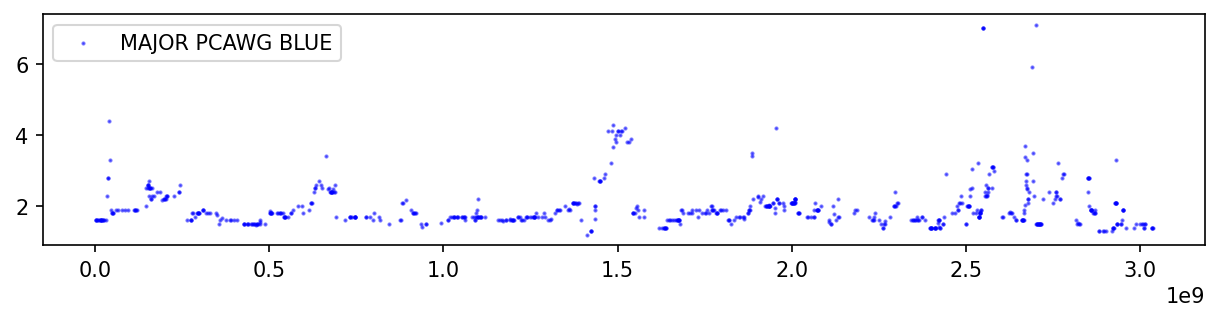

In [11]:
fig, ax = plt.subplots(1, 1, figsize=(10, 2), dpi=150)
plot_dots(ax, gene_groups_df, "major_cn", "blue", "MAJOR PCAWG BLUE", .5, 1)
ax.legend()

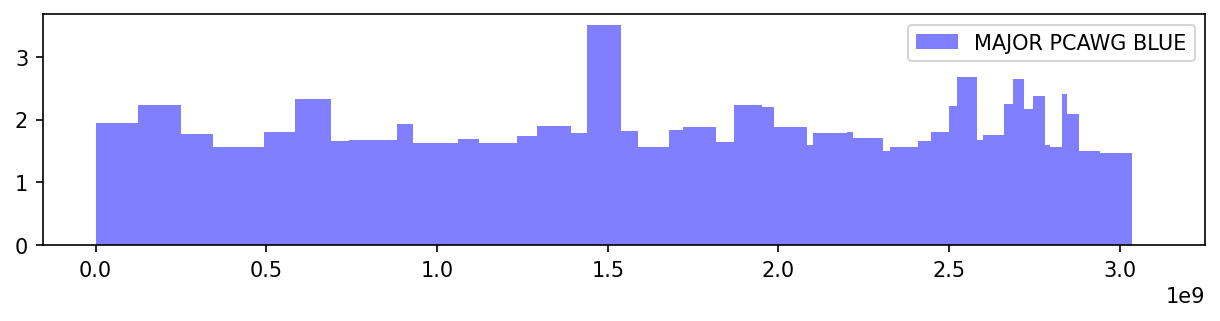

In [12]:
fig, ax = plt.subplots(1, 1, figsize=(10, 2), dpi=150)
plot_bars(ax, pcawg_arms_groups_df, "major_cn", "blue", "MAJOR PCAWG BLUE", .5)
ax.legend()

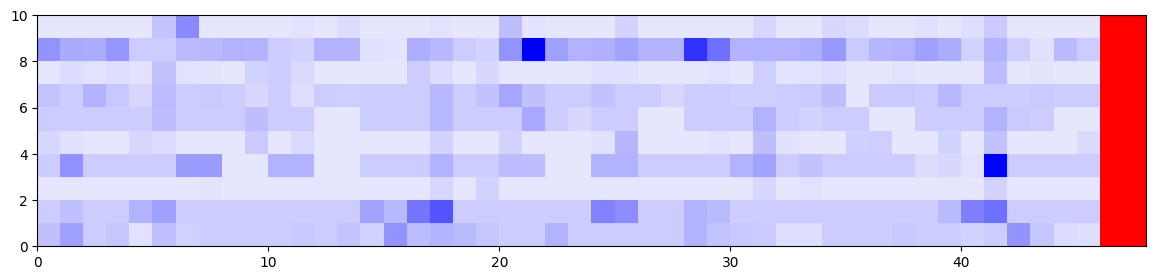

In [13]:
fig, ax = plt.subplots(1, 1, figsize=(24, 3))
plot_CN_heatmap(ax, pcawg_arms_bin_df, "major_cn");

# Figures

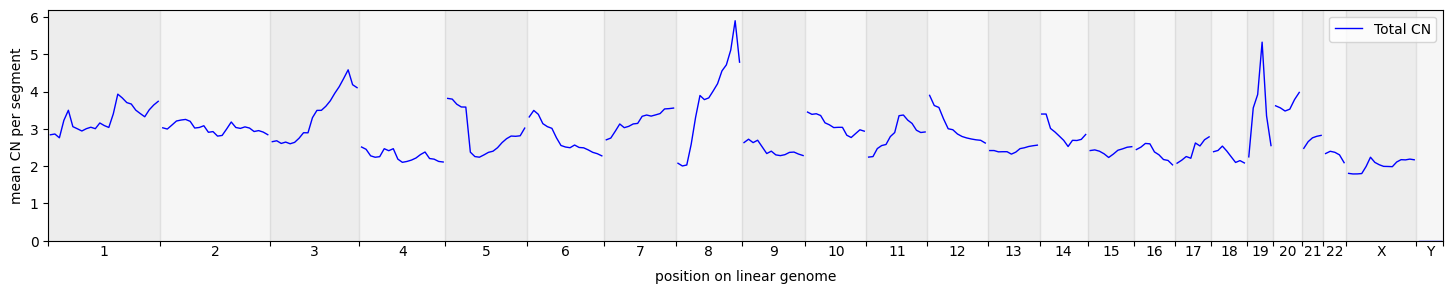

In [14]:
fig_lines(pcawg_50_groups_df, column="total_cn", label="Total CN", color="blue");
plt.savefig(pjoin(docs_path, "lines.png"), dpi=150)

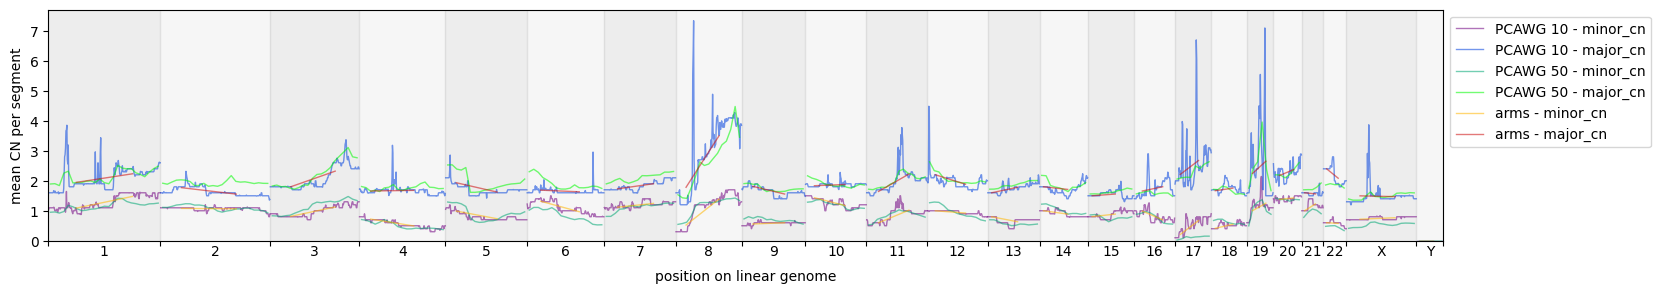

In [15]:
fig, ax = fig_lines([pcawg_10_groups_df, pcawg_50_groups_df, pcawg_arms_groups_df], label=["PCAWG 10", "PCAWG 50", "arms"], column=["minor_cn", "major_cn"])

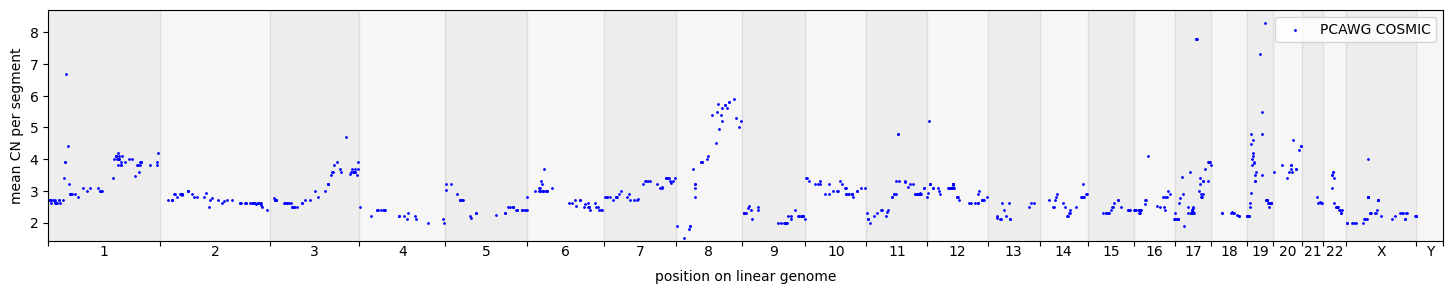

In [16]:
fig_dots(gene_groups_df, column="total_cn", label="PCAWG COSMIC");
plt.savefig(pjoin(docs_path, "dots.png"), dpi=150)

(<Figure size 1800x300 with 1 Axes>,
 <Axes: xlabel='position on linear genome', ylabel='mean CN per segment'>)

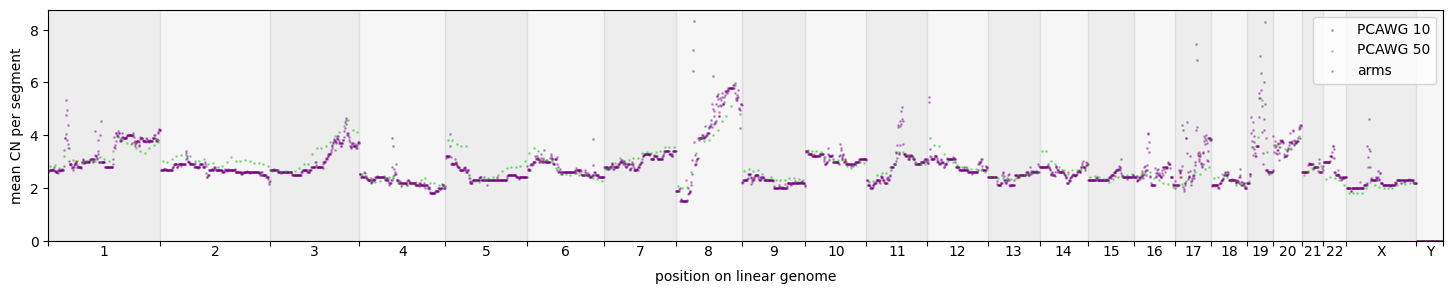

In [17]:
fig_dots([pcawg_10_groups_df, pcawg_50_groups_df, pcawg_arms_groups_df], ["PCAWG 10", "PCAWG 50", "arms"], column="total_cn")

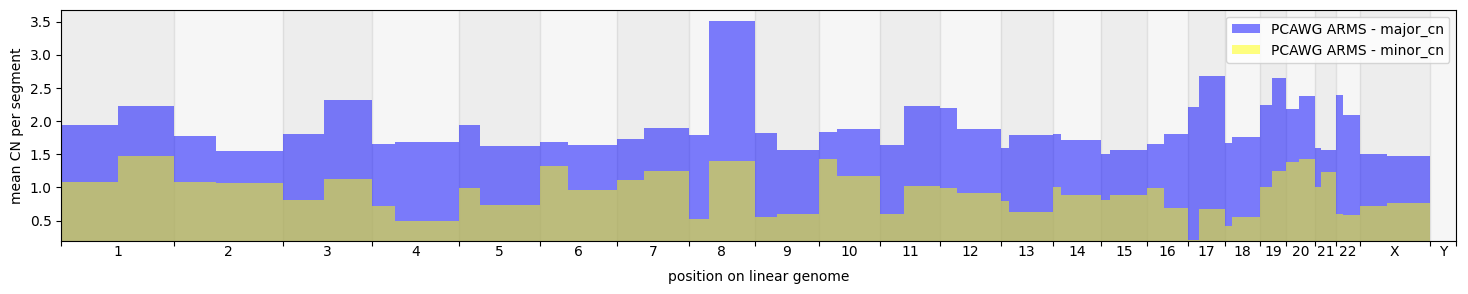

In [18]:
fig_bars(drop_Y(pcawg_arms_groups_df), column=["major_cn", "minor_cn"], color=["blue", "yellow"], label="PCAWG ARMS");
plt.savefig(pjoin(docs_path, "bars.png"), dpi=150)

## Single Chrom Only

In [15]:
step_size = int(1e6)
# only keep gaps at least half the step size
gaps_hg19_segs = tuples_to_segments(hg19.gaps)
genome_segs = genome_to_segments(hg19)
merged_hg19_gaps = merge_segments(gaps_hg19_segs)
filtered_gaps = filter_min_size(merged_hg19_gaps, step_size // 2)
filtered_genome = segment_difference(genome_segs, filtered_gaps)
filtered_segs = split_segments(filtered_genome, step_size)
filtered_cns = aggregate_by_segments(cns_head(pcawg_cns_df, 10), filtered_segs)

Binning chr (231/231)


Text(0.5, 1.0, 'Mean Copy Number across the genome, gaps removed')

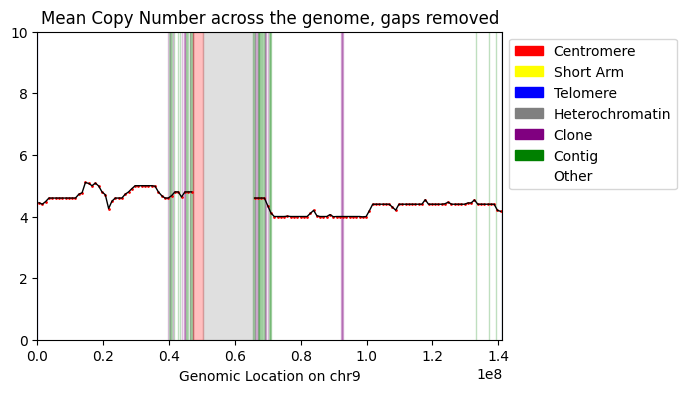

In [17]:
with_loc = add_cns_loc(filtered_cns)
grouped_bins = group_samples(with_loc)
fig, ax = plt.subplots(1, 1, figsize=(6, 4), dpi=100)
plot_gaps(ax, alpha=.25, y_max=10, chrom="chr9")
add_gap_legend(ax)
plot_lines(ax, grouped_bins, "total_cn", color="black", chrom="chr9")
plot_dots(ax, grouped_bins, "total_cn", color="red", chrom="chr9")
# no_y_ticks(ax)
# add lables
ax.set_xlabel("Genomic Location on chr9")
# ax.set_ylabel("Mean Copy Number")
ax.set_title("Mean Copy Number across the genome, gaps removed")

# CN Heatmaps

Figure size in inches: [18.    1.36] (Width x Height)
Ax size in inches: [17.7         0.87411502] (Width x Height)
Ax coordinates within the figure:
	Left: 0.00833333333333336
	Bottom: 0.1786341835481846
	Right: 0.9916666666666667
	Top: 0.8213658164518154
image_pixes:  [(607, 30363)]
dpi:  100
Top size:  0.1323529411764706


(<Figure size 1800x136 with 2 Axes>,
 <Axes: xlabel='total_cn', ylabel='sample'>)

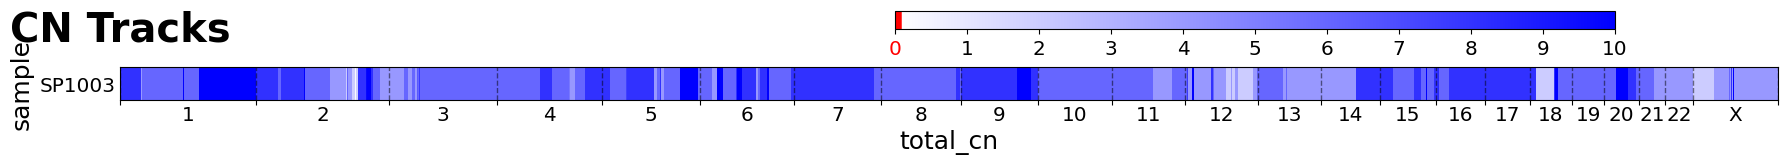

In [18]:
fig_CN_heatmap(pcawg_1_bin_df, print_info=True, column="total_cn", max_cn=10)

Aggregated into 554 CNS.                                        


D:\Ubuntu\CNSistent\cns\process\segmentation.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cns_df["length"] = (cns_df["end"] - cns_df["start"]).astype(np.uint32)
D:\Ubuntu\CNSistent\cns\process\segmentation.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cns_df["mid"] = cns_df["start"] + cns_df["length"] // 2
D:\Ubuntu\CNSistent\cns\process\segmentation.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = val

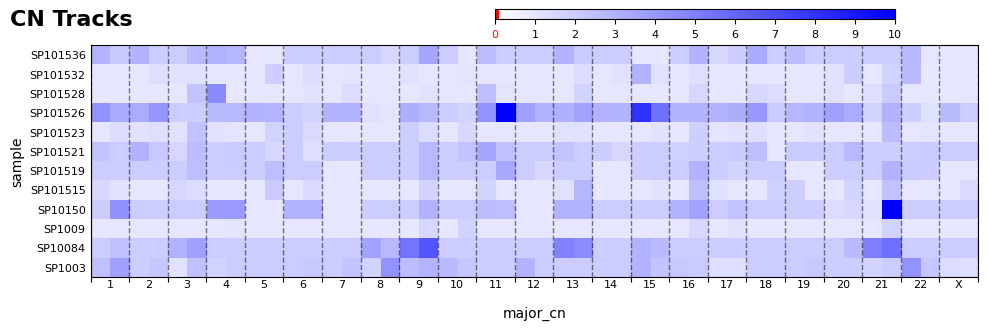

In [19]:
subset_arms = aggregate_by_break_type(cns_head(pcawg_cns_df, 12), "arms", hg19)
subset_arms = add_cns_loc(drop_Y(subset_arms))
fig_CN_heatmap(subset_arms, width=10, column="major_cn")
save_doc_fig("heatmap_arms.png")

Figure size in inches: [6. 5.] (Width x Height)
Ax size in inches: [0.90338194 4.7       ] (Width x Height)
Ax coordinates within the figure:
	Left: 0.2741545138888888
	Bottom: 0.02999999999999997
	Right: 0.7258454861111112
	Top: 0.97
image_pixes:  [(10, 2), (10, 2), (10, 2)]
dpi:  100
Top size:  0.04


(<Figure size 600x500 with 4 Axes>,
 array([<Axes: xlabel='major_cn', ylabel='sample'>,
        <Axes: xlabel='minor_cn'>, <Axes: xlabel='total_cn'>], dtype=object))

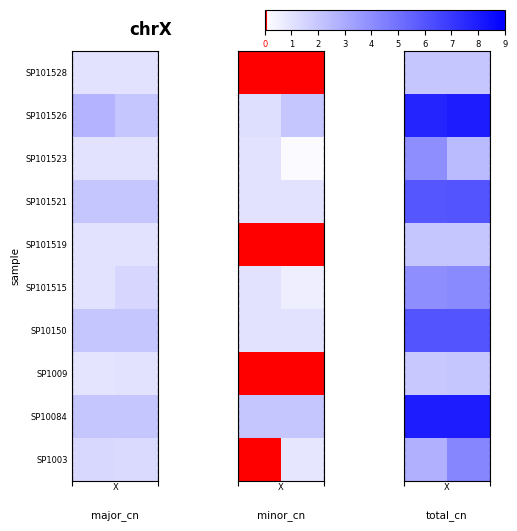

In [19]:
fig_CN_heatmap(pcawg_arms_bin_df, chrom="chrX", label="chrX", print_info=True, max_cn=10)

Figure size in inches: [16.   2.6] (Width x Height)
Ax size in inches: [7.46010417 1.88846801] (Width x Height)
Ax coordinates within the figure:
	Left: 0.03374348958333351
	Bottom: 0.1368330745293343
	Right: 0.9662565104166665
	Top: 0.8631669254706658
image_pixes:  [(620, 3093), (620, 3093)]
dpi:  100
Top size:  0.03076923076923077


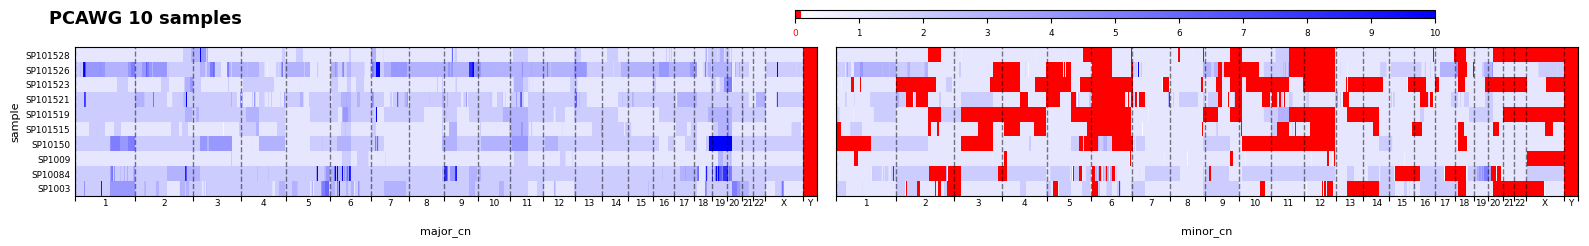

In [20]:
fig_CN_heatmap(pcawg_10_bin_df, "PCAWG 10 samples", width=16, column=["major_cn", "minor_cn"], max_cn=10, print_info=True)
# save to ../../docs/tracks.png
plt.savefig(pjoin(docs_path, "tracks.png"), dpi=300)

(<Figure size 700x800 with 2 Axes>, <Axes: xlabel='total_cn', ylabel='sample'>)

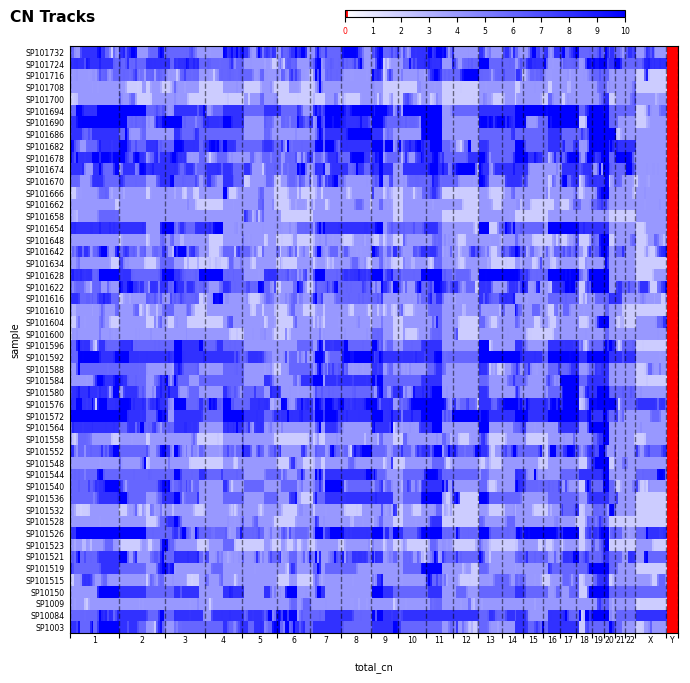

In [21]:
fig_CN_heatmap(pcawg_50_bin_df, width=7, column="total_cn", max_cn=10)

In [22]:
# pcawg_500_bin_df = add_cns_loc(bin_by_break_type(cns_head(pcawg_cns_df, 500), 10_000_000))
# print("Creating heatmap.... ")
# fig_CN_heatmap(pcawg_500_bin_df, column="total_cn");

Binning chr (11784/11784)
Creating heatmap.... 
